In [1]:
import pandas as pd

ot = pd.read_csv("/data/projects/punim0478/setiawand/bible-nmt/ebible-corpus/dhao-eng/engwebp/aligned-eng-engwebp-ot.csv")
nt = pd.read_csv("/data/projects/punim0478/setiawand/bible-nmt/ebible-corpus/dhao-eng/engwebp/aligned-eng-engwebp-nt.csv")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk import ngrams
from nltk.tokenize import word_tokenize
import string

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
# Extract source text from both dataframes
ot_text = ot['source_text'].dropna().tolist()
nt_text = nt['source_text'].dropna().tolist()

print(f"OT verses: {len(ot_text)}")
print(f"NT verses: {len(nt_text)}")
print(f"\nSample OT text: {ot_text[0]}")
print(f"Sample NT text: {nt_text[0]}")


OT verses: 1419
NT verses: 7644

Sample OT text: in the beginning, god created the heavens and the earth.
Sample NT text: the book of the genealogy of jesus christ, the son of david, the son of abraham. abraham became the father of isaac. isaac became the father of jacob. jacob became the father of judah and his brothers.


In [4]:
# Tokenization function (lowercase and clean)
def tokenize_text(text_list):
    """Tokenize a list of text strings into words."""
    tokens = []
    for text in text_list:
        # Convert to lowercase and tokenize
        words = text.lower().split()
        # Remove punctuation from each word
        words = [word.strip(string.punctuation) for word in words]
        # Filter out empty strings
        words = [word for word in words if word]
        tokens.extend(words)
    return tokens

# Tokenize both corpora
ot_tokens = tokenize_text(ot_text)
nt_tokens = tokenize_text(nt_text)

print(f"OT total tokens: {len(ot_tokens):,}")
print(f"NT total tokens: {len(nt_tokens):,}")
print(f"OT unique tokens: {len(set(ot_tokens)):,}")
print(f"NT unique tokens: {len(set(nt_tokens)):,}")


OT total tokens: 35,766
NT total tokens: 174,633
OT unique tokens: 2,588
NT unique tokens: 6,267


## 1. Vocabulary Overlap Analysis

Calculate the percentage of unique words (unigrams) and phrases (bigrams, trigrams) in the OT that are also present in the NT training data.


In [5]:
# Function to generate n-grams
def get_ngrams(tokens, n):
    """Generate n-grams from a list of tokens."""
    return [tuple(gram) for gram in zip(*[tokens[i:] for i in range(n)])]

# Generate unigrams, bigrams, and trigrams
ot_unigrams = set(ot_tokens)
nt_unigrams = set(nt_tokens)

ot_bigrams = set(get_ngrams(ot_tokens, 2))
nt_bigrams = set(get_ngrams(nt_tokens, 2))

ot_trigrams = set(get_ngrams(ot_tokens, 3))
nt_trigrams = set(get_ngrams(nt_tokens, 3))

# Calculate overlap percentages
unigram_overlap = len(ot_unigrams & nt_unigrams) / len(ot_unigrams) * 100
bigram_overlap = len(ot_bigrams & nt_bigrams) / len(ot_bigrams) * 100
trigram_overlap = len(ot_trigrams & nt_trigrams) / len(ot_trigrams) * 100

print("=== Vocabulary Overlap Analysis ===")
print(f"\nUnigrams (words):")
print(f"  OT unique: {len(ot_unigrams):,}")
print(f"  NT unique: {len(nt_unigrams):,}")
print(f"  Overlap: {len(ot_unigrams & nt_unigrams):,} ({unigram_overlap:.2f}%)")

print(f"\nBigrams (2-word phrases):")
print(f"  OT unique: {len(ot_bigrams):,}")
print(f"  NT unique: {len(nt_bigrams):,}")
print(f"  Overlap: {len(ot_bigrams & nt_bigrams):,} ({bigram_overlap:.2f}%)")

print(f"\nTrigrams (3-word phrases):")
print(f"  OT unique: {len(ot_trigrams):,}")
print(f"  NT unique: {len(nt_trigrams):,}")
print(f"  Overlap: {len(ot_trigrams & nt_trigrams):,} ({trigram_overlap:.2f}%)")


=== Vocabulary Overlap Analysis ===

Unigrams (words):
  OT unique: 2,588
  NT unique: 6,267
  Overlap: 1,734 (67.00%)

Bigrams (2-word phrases):
  OT unique: 15,317
  NT unique: 57,182
  Overlap: 6,043 (39.45%)

Trigrams (3-word phrases):
  OT unique: 27,071
  NT unique: 121,293
  Overlap: 4,272 (15.78%)


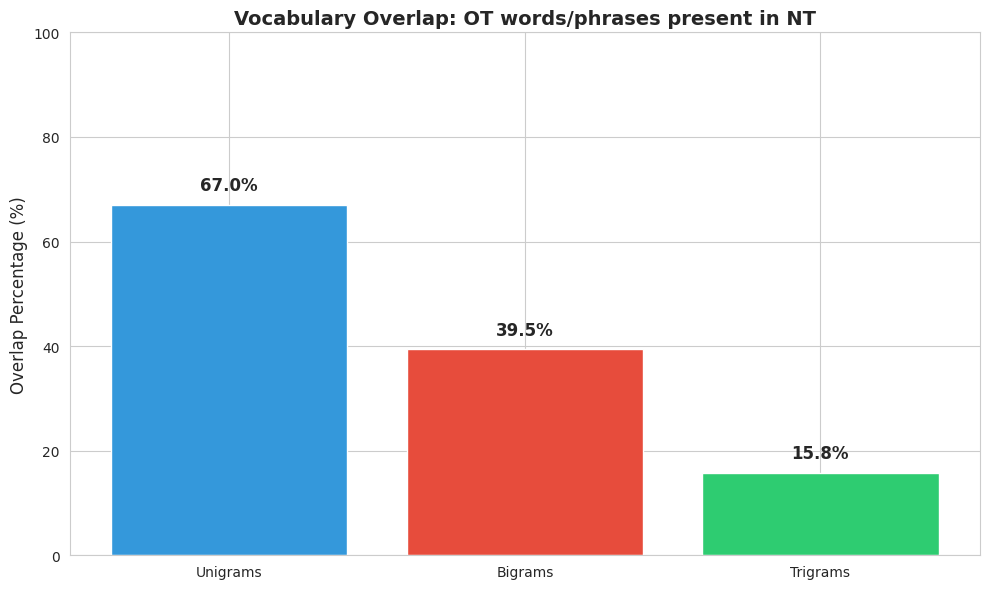

In [6]:
# Visualize vocabulary overlap
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Unigrams', 'Bigrams', 'Trigrams']
overlap_percentages = [unigram_overlap, bigram_overlap, trigram_overlap]

bars = ax.bar(categories, overlap_percentages, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Overlap Percentage (%)', fontsize=12)
ax.set_title('Vocabulary Overlap: OT words/phrases present in NT', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

# Add percentage labels on bars
for bar, pct in zip(bars, overlap_percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 2. Type-Token Ratio (TTR)

Measure the lexical richness of each corpus. A significant difference in TTR suggests a difference in stylistic complexity and vocabulary diversity.


In [7]:
# Calculate Type-Token Ratio
ot_ttr = len(set(ot_tokens)) / len(ot_tokens)
nt_ttr = len(set(nt_tokens)) / len(nt_tokens)

print("=== Type-Token Ratio (TTR) Analysis ===")
print(f"\nOT TTR: {ot_ttr:.4f}")
print(f"NT TTR: {nt_ttr:.4f}")
print(f"Difference: {abs(ot_ttr - nt_ttr):.4f} ({abs(ot_ttr - nt_ttr)/min(ot_ttr, nt_ttr)*100:.2f}% relative difference)")

# Calculate standardized TTR (using samples to account for text length differences)
def calculate_sttr(tokens, sample_size=1000, num_samples=100):
    """Calculate standardized TTR by averaging TTR over multiple samples."""
    if len(tokens) < sample_size:
        return len(set(tokens)) / len(tokens)
    
    ttrs = []
    for _ in range(num_samples):
        start_idx = np.random.randint(0, len(tokens) - sample_size)
        sample = tokens[start_idx:start_idx + sample_size]
        ttrs.append(len(set(sample)) / len(sample))
    
    return np.mean(ttrs)

ot_sttr = calculate_sttr(ot_tokens)
nt_sttr = calculate_sttr(nt_tokens)

print(f"\nStandardized TTR (1000-token samples):")
print(f"OT STTR: {ot_sttr:.4f}")
print(f"NT STTR: {nt_sttr:.4f}")
print(f"Difference: {abs(ot_sttr - nt_sttr):.4f}")


=== Type-Token Ratio (TTR) Analysis ===

OT TTR: 0.0724
NT TTR: 0.0359
Difference: 0.0365 (101.63% relative difference)

Standardized TTR (1000-token samples):
OT STTR: 0.2863
NT STTR: 0.3383
Difference: 0.0520


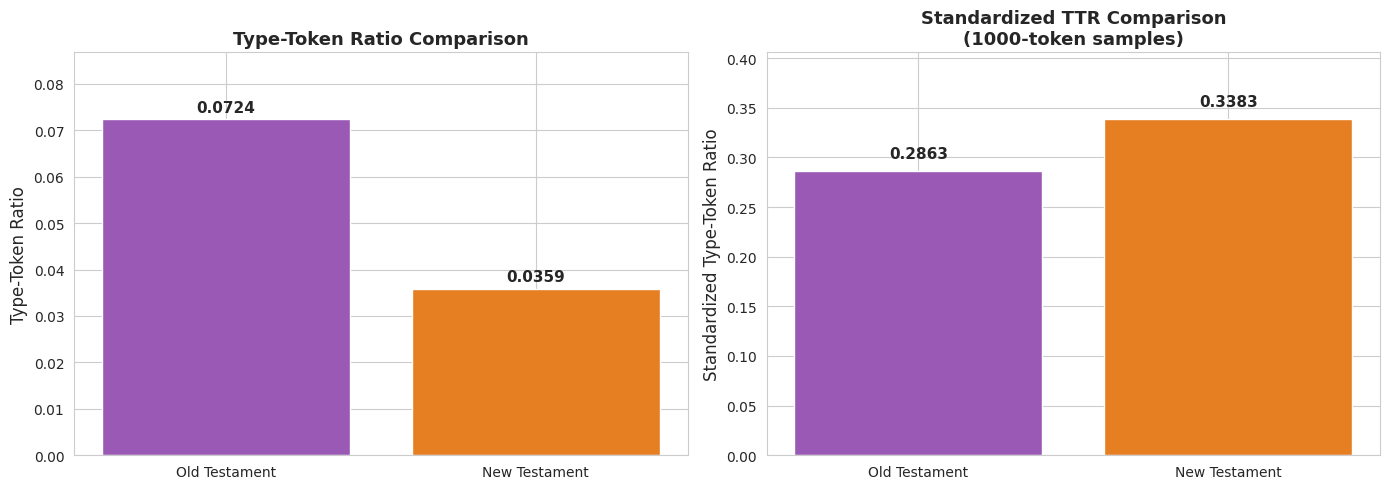

In [8]:
# Visualize TTR comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Regular TTR
corpora = ['Old Testament', 'New Testament']
ttr_values = [ot_ttr, nt_ttr]
colors = ['#9b59b6', '#e67e22']

bars1 = ax1.bar(corpora, ttr_values, color=colors)
ax1.set_ylabel('Type-Token Ratio', fontsize=12)
ax1.set_title('Type-Token Ratio Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(ttr_values) * 1.2)

for bar, val in zip(bars1, ttr_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Standardized TTR
sttr_values = [ot_sttr, nt_sttr]
bars2 = ax2.bar(corpora, sttr_values, color=colors)
ax2.set_ylabel('Standardized Type-Token Ratio', fontsize=12)
ax2.set_title('Standardized TTR Comparison\n(1000-token samples)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(sttr_values) * 1.2)

for bar, val in zip(bars2, sttr_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Out-of-Vocabulary (OOV) Rate

Quantify the percentage of words in the OT that do not appear in the NT vocabulary. A high OOV rate demonstrates the out-of-domain problem.


In [9]:
# Calculate OOV rate: words in OT that are NOT in NT vocabulary
ot_oov_types = ot_unigrams - nt_unigrams  # Unique words in OT not in NT
oov_type_rate = len(ot_oov_types) / len(ot_unigrams) * 100

# Calculate token-level OOV rate (how many actual word occurrences are OOV)
ot_oov_tokens = [token for token in ot_tokens if token not in nt_unigrams]
oov_token_rate = len(ot_oov_tokens) / len(ot_tokens) * 100

print("=== Out-of-Vocabulary (OOV) Analysis ===")
print(f"\nOT words NOT in NT vocabulary:")
print(f"  Type-level (unique words): {len(ot_oov_types):,} / {len(ot_unigrams):,} = {oov_type_rate:.2f}%")
print(f"  Token-level (total occurrences): {len(ot_oov_tokens):,} / {len(ot_tokens):,} = {oov_token_rate:.2f}%")

# Show some examples of OOV words
ot_token_counts = Counter(ot_tokens)
oov_examples = [(word, ot_token_counts[word]) for word in ot_oov_types]
oov_examples.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 20 most frequent OOV words in OT:")
for word, count in oov_examples[:20]:
    print(f"  '{word}': {count:,} occurrences")


=== Out-of-Vocabulary (OOV) Analysis ===

OT words NOT in NT vocabulary:
  Type-level (unique words): 854 / 2,588 = 33.00%
  Token-level (total occurrences): 1,954 / 35,766 = 5.46%

Top 20 most frequent OOV words in OT:
  'abram': 55 occurrences
  'laban': 48 occurrences
  'flocks': 28 occurrences
  'leah': 28 occurrences
  'abimelech': 23 occurrences
  'camels': 22 occurrences
  'sarai': 16 occurrences
  'ishmael': 16 occurrences
  'donkeys': 15 occurrences
  'dreamed': 14 occurrences
  'herds': 13 occurrences
  'youngest': 13 occurrences
  'heth': 13 occurrences
  'ephron': 12 occurrences
  'bethel': 12 occurrences
  'esau's': 12 occurrences
  'beersheba': 11 occurrences
  'paddan': 11 occurrences
  'son's': 11 occurrences
  'chiefs': 11 occurrences


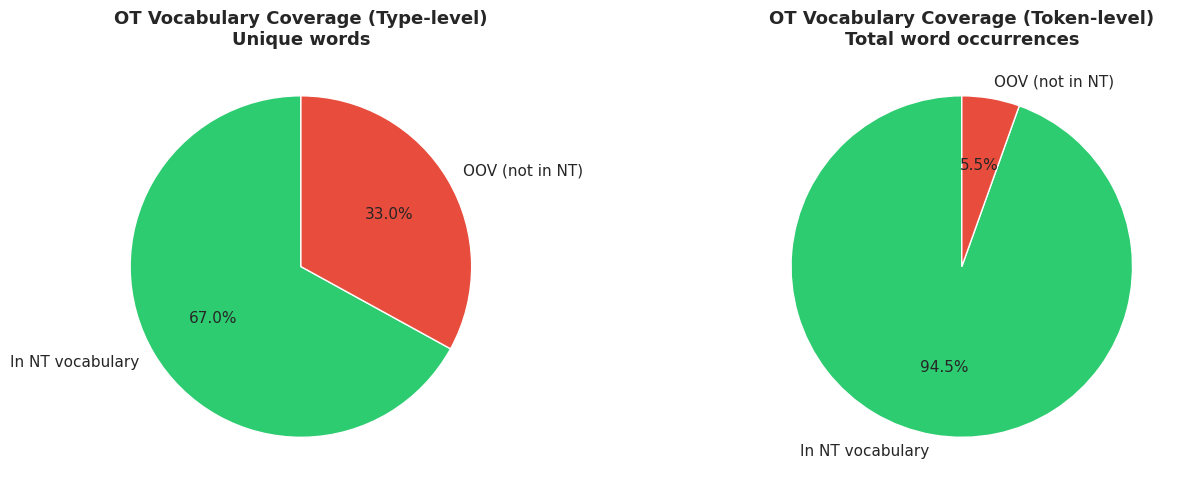

In [10]:
# Visualize OOV rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Type-level OOV
categories_type = ['In NT vocabulary', 'OOV (not in NT)']
values_type = [100 - oov_type_rate, oov_type_rate]
colors_pie = ['#2ecc71', '#e74c3c']

wedges1, texts1, autotexts1 = ax1.pie(values_type, labels=categories_type, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90, textprops={'fontsize': 11})
ax1.set_title('OT Vocabulary Coverage (Type-level)\nUnique words', fontsize=13, fontweight='bold')

# Token-level OOV
categories_token = ['In NT vocabulary', 'OOV (not in NT)']
values_token = [100 - oov_token_rate, oov_token_rate]

wedges2, texts2, autotexts2 = ax2.pie(values_token, labels=categories_token, autopct='%1.1f%%',
                                        colors=colors_pie, startangle=90, textprops={'fontsize': 11})
ax2.set_title('OT Vocabulary Coverage (Token-level)\nTotal word occurrences', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Frequency Distribution of Key Terms

Identify key theological terms, names, and places specific to each testament. Show that the frequency distributions of these terms are starkly different across the two corpora.


In [11]:
# Define key terms for each testament
ot_key_terms = [
    'moses', 'abraham', 'israel', 'jerusalem', 'pharaoh', 'egypt', 
    'solomon', 'david', 'temple', 'covenant', 'prophet', 'judah',
    'babylon', 'levites', 'sabbath', 'aaron', 'joshua', 'samuel'
]

nt_key_terms = [
    'jesus', 'christ', 'disciples', 'apostles', 'gospel', 'pharisees',
    'paul', 'peter', 'john', 'matthew', 'gentiles', 'church',
    'resurrection', 'crucified', 'baptism', 'faith', 'grace', 'spirit'
]

# Count frequencies in both corpora
ot_counter = Counter(ot_tokens)
nt_counter = Counter(nt_tokens)

# Calculate frequencies for OT-specific terms
print("=== Frequency Distribution of Key Terms ===")
print("\nOT-specific terms:")
print(f"{'Term':<15} {'OT Count':>10} {'NT Count':>10} {'OT/NT Ratio':>12}")
print("-" * 50)

ot_term_data = []
for term in ot_key_terms:
    ot_count = ot_counter.get(term, 0)
    nt_count = nt_counter.get(term, 0)
    ratio = ot_count / nt_count if nt_count > 0 else float('inf')
    ot_term_data.append((term, ot_count, nt_count, ratio))
    ratio_str = f"{ratio:.2f}" if ratio != float('inf') else "∞"
    print(f"{term:<15} {ot_count:>10,} {nt_count:>10,} {ratio_str:>12}")

print("\n\nNT-specific terms:")
print(f"{'Term':<15} {'OT Count':>10} {'NT Count':>10} {'NT/OT Ratio':>12}")
print("-" * 50)

nt_term_data = []
for term in nt_key_terms:
    ot_count = ot_counter.get(term, 0)
    nt_count = nt_counter.get(term, 0)
    ratio = nt_count / ot_count if ot_count > 0 else float('inf')
    nt_term_data.append((term, ot_count, nt_count, ratio))
    ratio_str = f"{ratio:.2f}" if ratio != float('inf') else "∞"
    print(f"{term:<15} {ot_count:>10,} {nt_count:>10,} {ratio_str:>12}")


=== Frequency Distribution of Key Terms ===

OT-specific terms:
Term              OT Count   NT Count  OT/NT Ratio
--------------------------------------------------
moses                    0         80         0.00
abraham                120         69         1.74
israel                  43         74         0.58
jerusalem                0        144         0.00
pharaoh                 78          3        26.00
egypt                   72         24         3.00
solomon                  0          9         0.00
david                    0         55         0.00
temple                   0        114         0.00
covenant                26         33         0.79
prophet                  1         70         0.01
judah                   27         14         1.93
babylon                  0         12         0.00
levites                  0          1         0.00
sabbath                  0         61         0.00
aaron                    0          4         0.00
joshua            

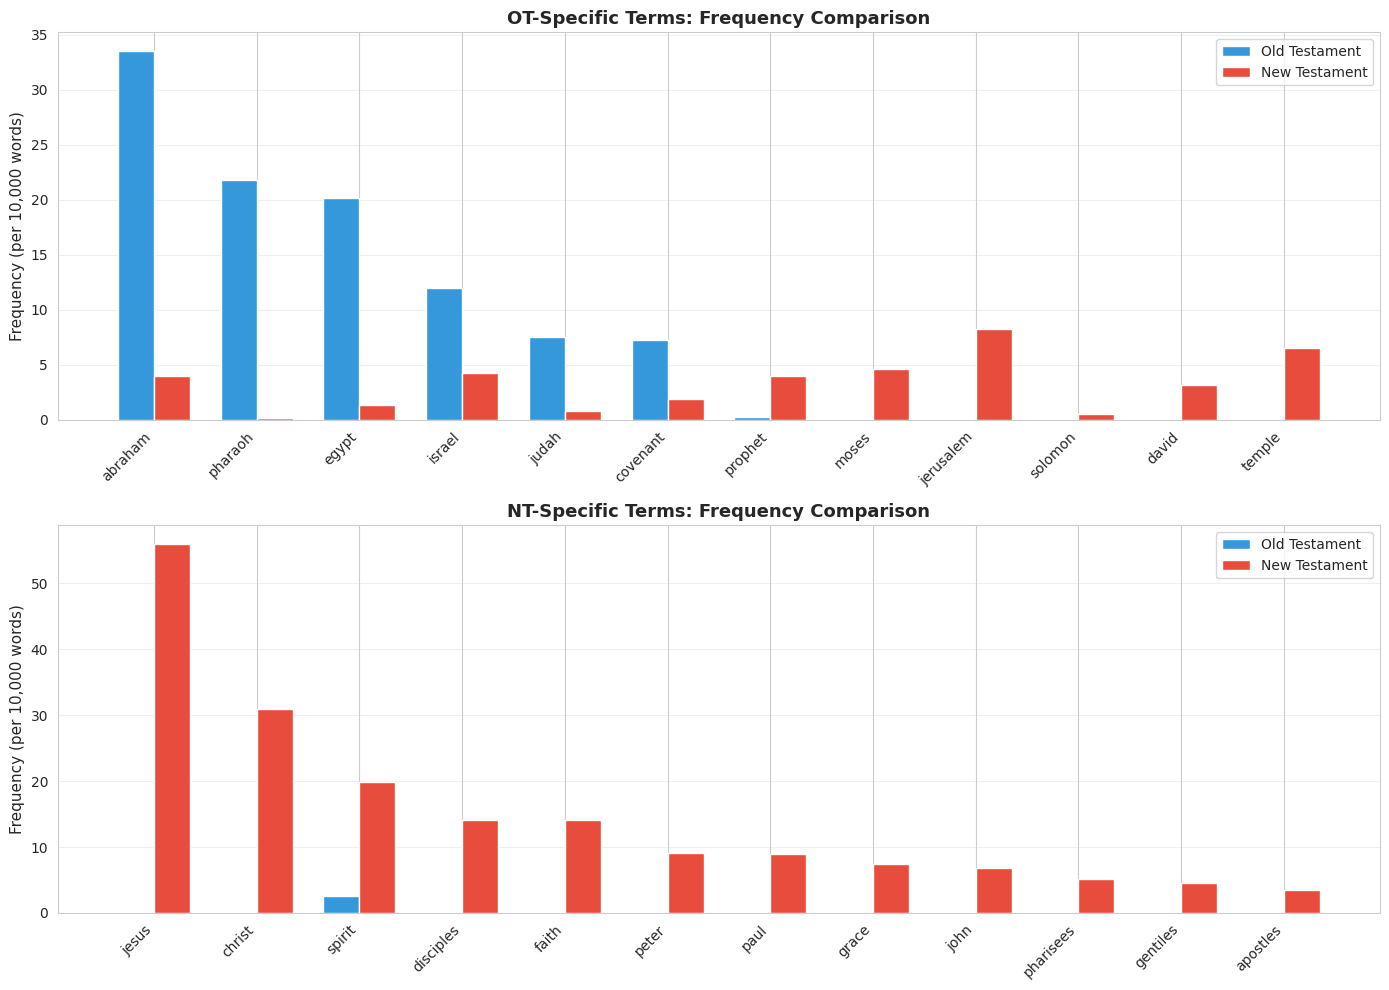

In [12]:
# Visualize key terms with bar charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# OT-specific terms (normalize by corpus size for fair comparison)
ot_corpus_size = len(ot_tokens)
nt_corpus_size = len(nt_tokens)

# Normalize frequencies per 10,000 words
ot_terms_sorted = sorted(ot_term_data, key=lambda x: x[1], reverse=True)[:12]
terms_ot = [x[0] for x in ot_terms_sorted]
ot_freq_normalized = [x[1] / ot_corpus_size * 10000 for x in ot_terms_sorted]
nt_freq_normalized_for_ot = [x[2] / nt_corpus_size * 10000 for x in ot_terms_sorted]

x = np.arange(len(terms_ot))
width = 0.35

bars1 = ax1.bar(x - width/2, ot_freq_normalized, width, label='Old Testament', color='#3498db')
bars2 = ax1.bar(x + width/2, nt_freq_normalized_for_ot, width, label='New Testament', color='#e74c3c')

ax1.set_ylabel('Frequency (per 10,000 words)', fontsize=11)
ax1.set_title('OT-Specific Terms: Frequency Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(terms_ot, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# NT-specific terms
nt_terms_sorted = sorted(nt_term_data, key=lambda x: x[2], reverse=True)[:12]
terms_nt = [x[0] for x in nt_terms_sorted]
ot_freq_normalized_for_nt = [x[1] / ot_corpus_size * 10000 for x in nt_terms_sorted]
nt_freq_normalized = [x[2] / nt_corpus_size * 10000 for x in nt_terms_sorted]

x2 = np.arange(len(terms_nt))

bars3 = ax2.bar(x2 - width/2, ot_freq_normalized_for_nt, width, label='Old Testament', color='#3498db')
bars4 = ax2.bar(x2 + width/2, nt_freq_normalized, width, label='New Testament', color='#e74c3c')

ax2.set_ylabel('Frequency (per 10,000 words)', fontsize=11)
ax2.set_title('NT-Specific Terms: Frequency Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(terms_nt, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


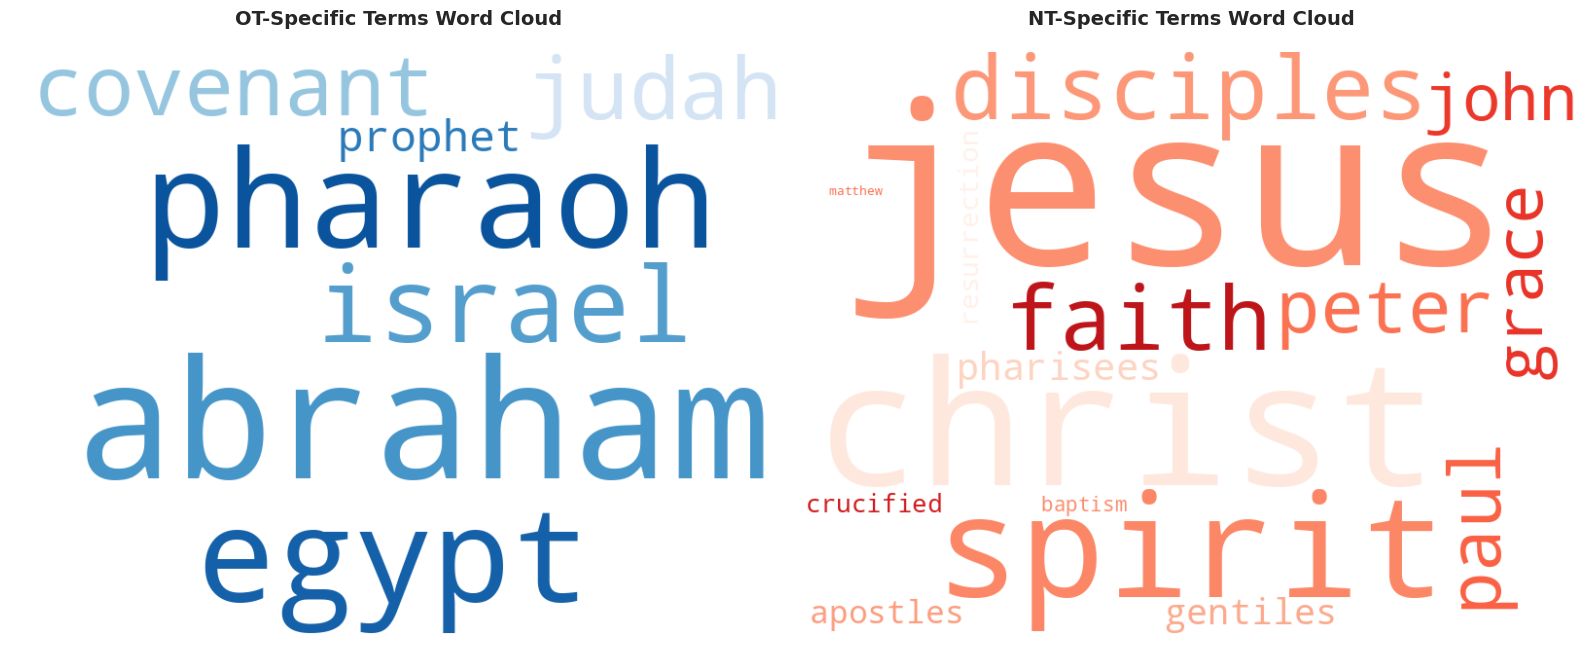

In [13]:
# Word clouds for visual representation of term distributions
from wordcloud import WordCloud

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Create word clouds with only key terms for focused visualization
ot_key_freq = {term: ot_counter.get(term, 0) for term in ot_key_terms}
nt_key_freq = {term: nt_counter.get(term, 0) for term in nt_key_terms}

# OT word cloud
wc_ot = WordCloud(width=800, height=600, background_color='white', 
                   colormap='Blues', relative_scaling=0.5).generate_from_frequencies(ot_key_freq)
ax1.imshow(wc_ot, interpolation='bilinear')
ax1.set_title('OT-Specific Terms Word Cloud', fontsize=14, fontweight='bold', pad=20)
ax1.axis('off')

# NT word cloud
wc_nt = WordCloud(width=800, height=600, background_color='white',
                   colormap='Reds', relative_scaling=0.5).generate_from_frequencies(nt_key_freq)
ax2.imshow(wc_nt, interpolation='bilinear')
ax2.set_title('NT-Specific Terms Word Cloud', fontsize=14, fontweight='bold', pad=20)
ax2.axis('off')

plt.tight_layout()
plt.show()


## Summary

This analysis demonstrates significant domain shift between the Old Testament (OT) and New Testament (NT):

1. **Vocabulary Overlap**: Shows how much of OT vocabulary appears in NT (lower overlap = greater domain shift)
2. **Type-Token Ratio**: Indicates lexical richness and complexity differences between the corpora
3. **OOV Rate**: Quantifies the percentage of OT words not found in NT vocabulary (direct measure of domain shift)
4. **Key Terms**: Demonstrates that theological terms, names, and places have drastically different frequency distributions across the two testaments

These metrics collectively provide strong evidence of domain shift, which is critical for understanding translation model performance when training on one testament and testing on another.


---

## Publication-Ready Figures

The following cells generate publication-quality figures suitable for research papers with:
- Colorblind-friendly palettes
- High DPI (300) for print quality
- Professional styling
- Clear, academic presentation


In [14]:
# Set publication-ready style
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5
})

# Colorblind-friendly palette (IBM Design palette)
colors_cb = {
    'blue': '#648FFF',      # Blue
    'purple': '#785EF0',    # Purple  
    'magenta': '#DC267F',   # Magenta
    'orange': '#FE6100',    # Orange
    'gold': '#FFB000',      # Gold
    'gray': '#666666'       # Gray
}


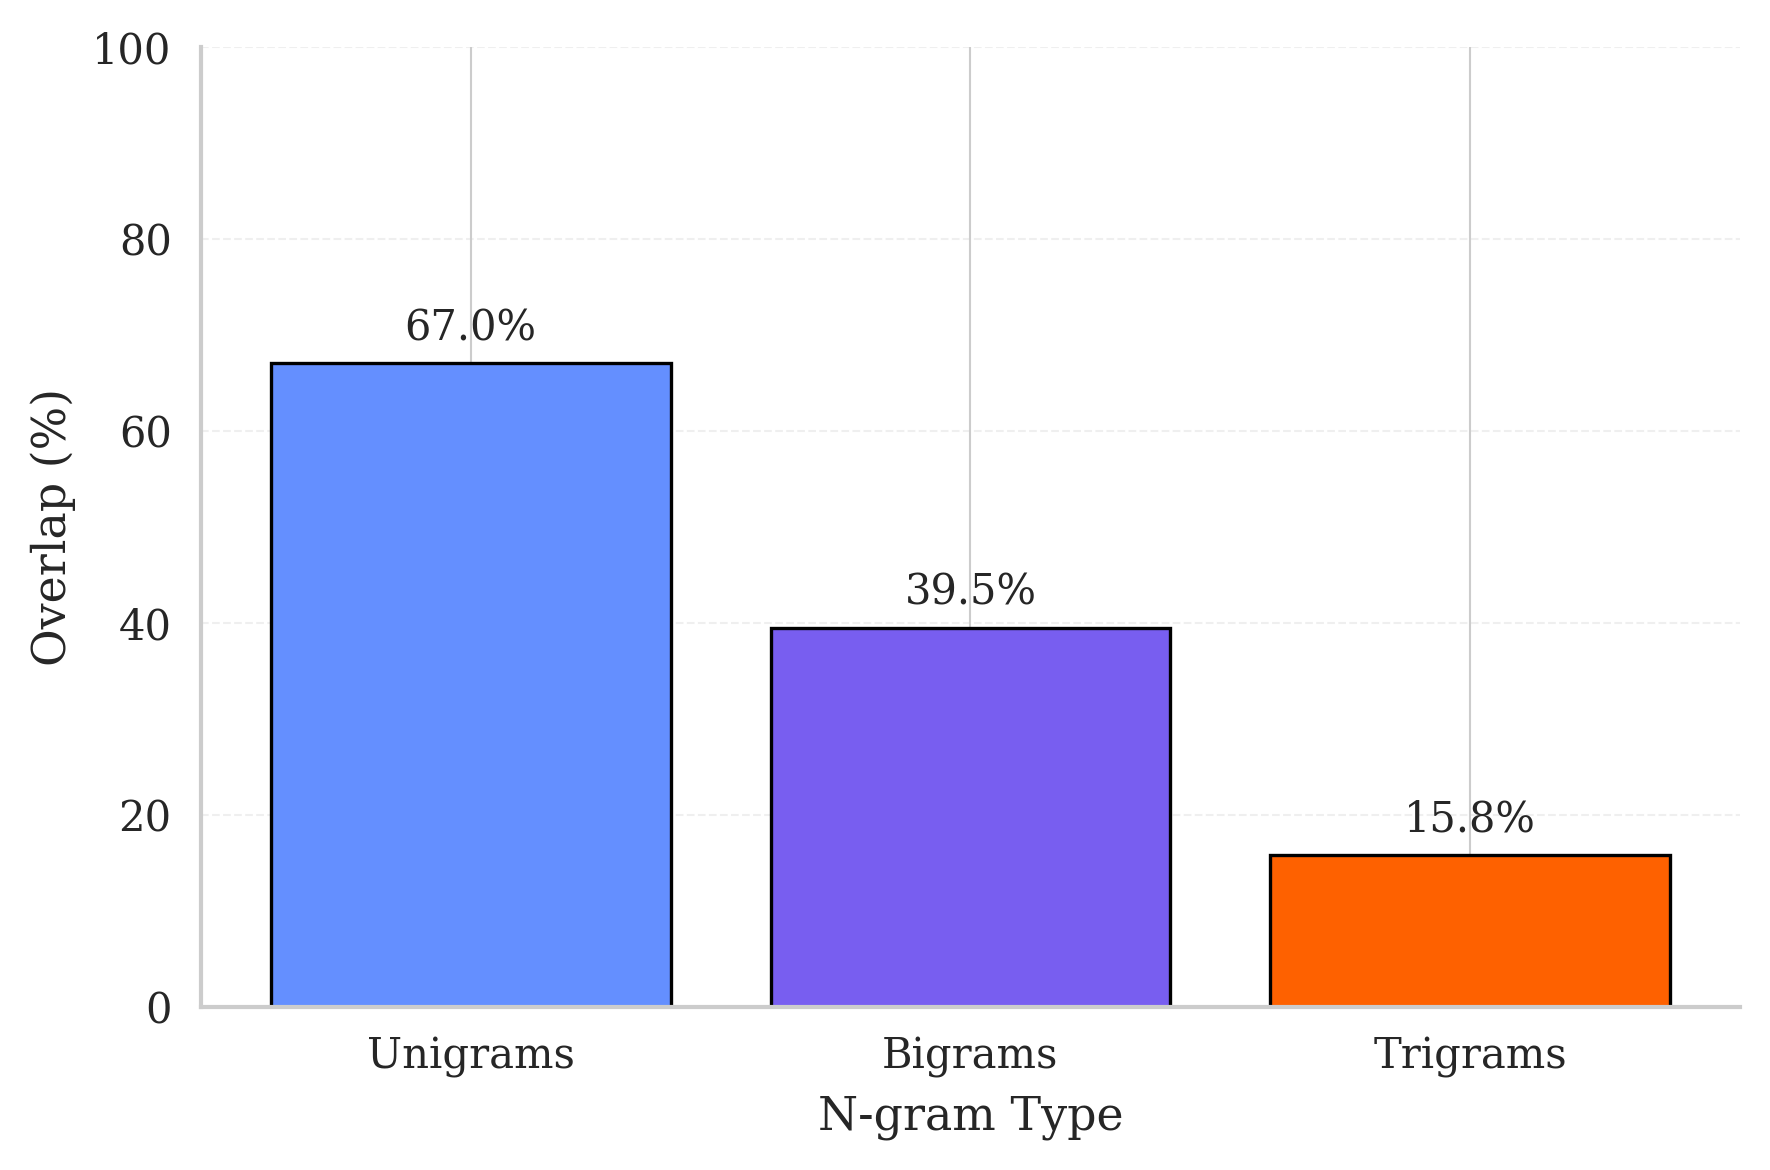

✓ Figure 1 saved: Vocabulary Overlap


In [15]:
# Figure 1: Vocabulary Overlap (Publication version)
fig, ax = plt.subplots(figsize=(6, 4))

categories = ['Unigrams', 'Bigrams', 'Trigrams']
overlap_percentages = [unigram_overlap, bigram_overlap, trigram_overlap]

bars = ax.bar(categories, overlap_percentages, 
              color=[colors_cb['blue'], colors_cb['purple'], colors_cb['orange']],
              edgecolor='black', linewidth=0.8)

ax.set_ylabel('Overlap (%)', fontsize=11)
ax.set_xlabel('N-gram Type', fontsize=11)
ax.set_ylim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, pct in zip(bars, overlap_percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig1_vocabulary_overlap.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig1_vocabulary_overlap.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ Figure 1 saved: Vocabulary Overlap")


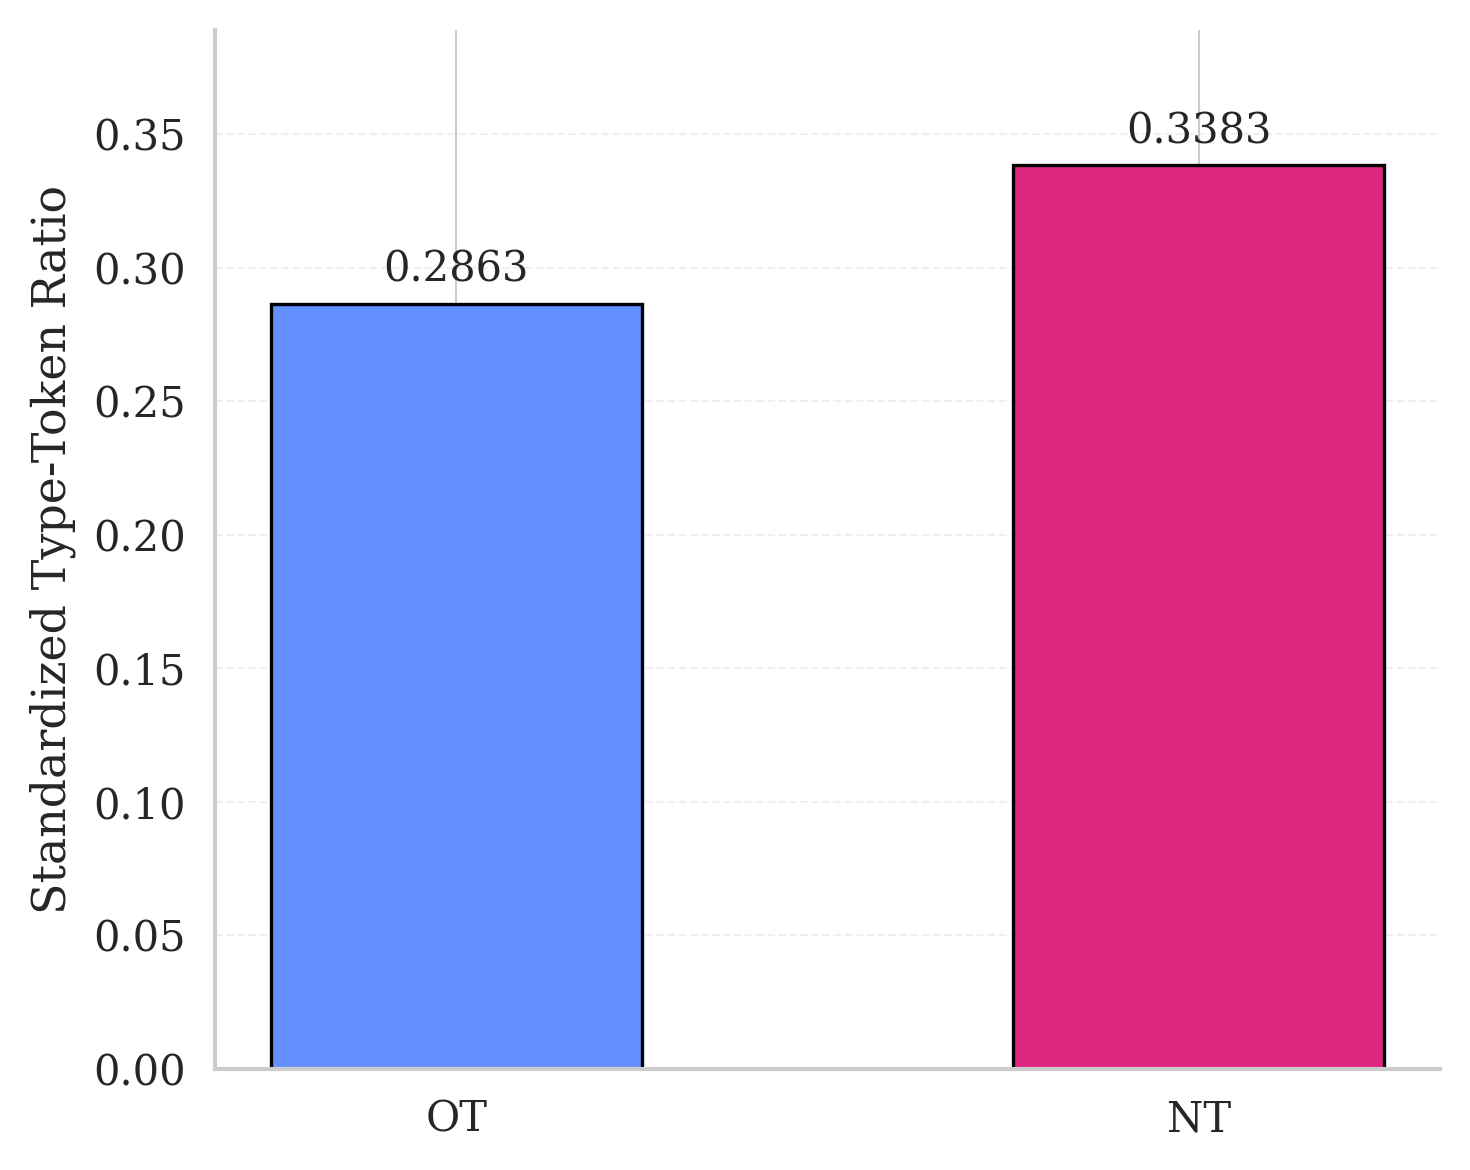

✓ Figure 2 saved: Type-Token Ratio


In [16]:
# Figure 2: Type-Token Ratio Comparison (Publication version)
fig, ax = plt.subplots(figsize=(5, 4))

corpora = ['OT', 'NT']
sttr_values = [ot_sttr, nt_sttr]

bars = ax.bar(corpora, sttr_values, 
              color=[colors_cb['blue'], colors_cb['magenta']],
              edgecolor='black', linewidth=0.8, width=0.5)

ax.set_ylabel('Standardized Type-Token Ratio', fontsize=11)
ax.set_ylim(0, max(sttr_values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, val in zip(bars, sttr_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig2_type_token_ratio.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig2_type_token_ratio.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ Figure 2 saved: Type-Token Ratio")


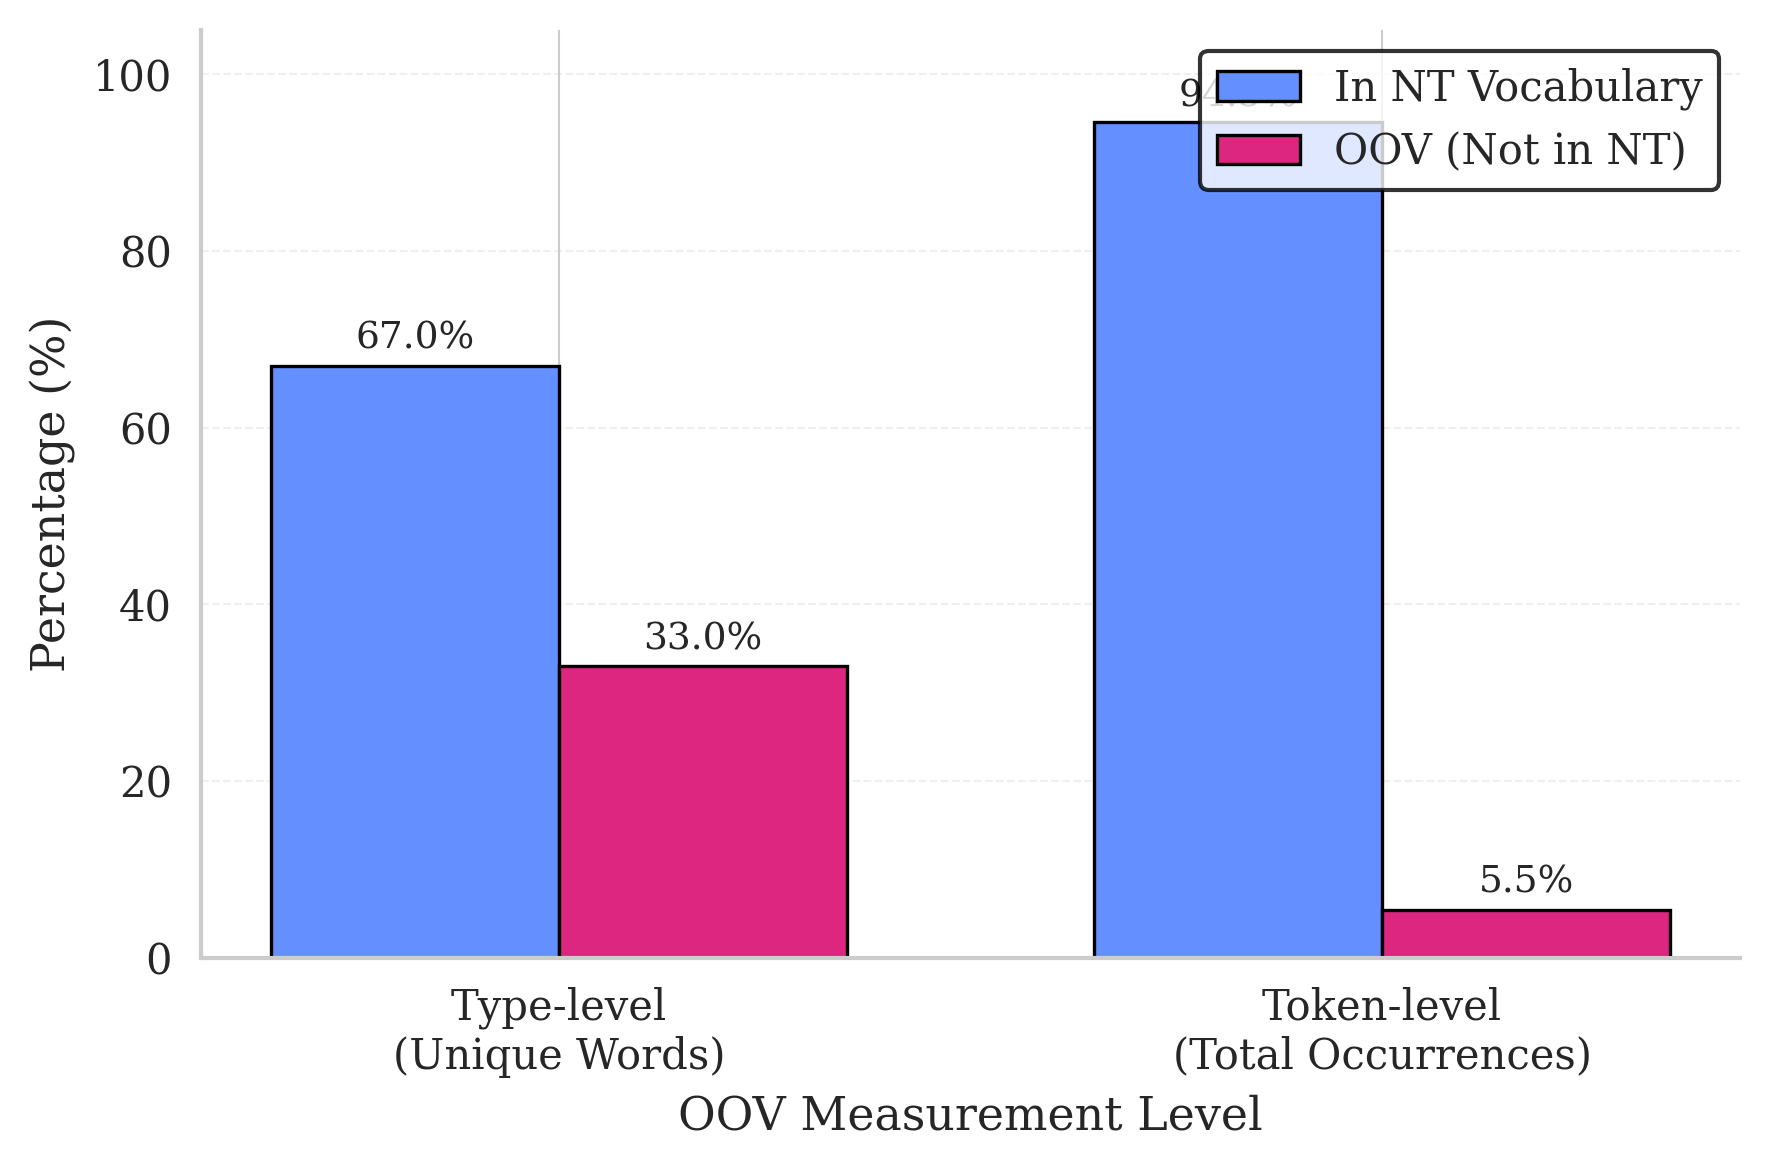

✓ Figure 3 saved: OOV Rate


In [17]:
# Figure 3: OOV Rate (Publication version - using bar chart instead of pie)
fig, ax = plt.subplots(figsize=(6, 4))

categories = ['Type-level\n(Unique Words)', 'Token-level\n(Total Occurrences)']
oov_rates = [oov_type_rate, oov_token_rate]
in_vocab_rates = [100 - oov_type_rate, 100 - oov_token_rate]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, in_vocab_rates, width, 
               label='In NT Vocabulary', color=colors_cb['blue'],
               edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, oov_rates, width,
               label='OOV (Not in NT)', color=colors_cb['magenta'],
               edgecolor='black', linewidth=0.8)

ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('OOV Measurement Level', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', frameon=True, edgecolor='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_oov_rate.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig3_oov_rate.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ Figure 3 saved: OOV Rate")


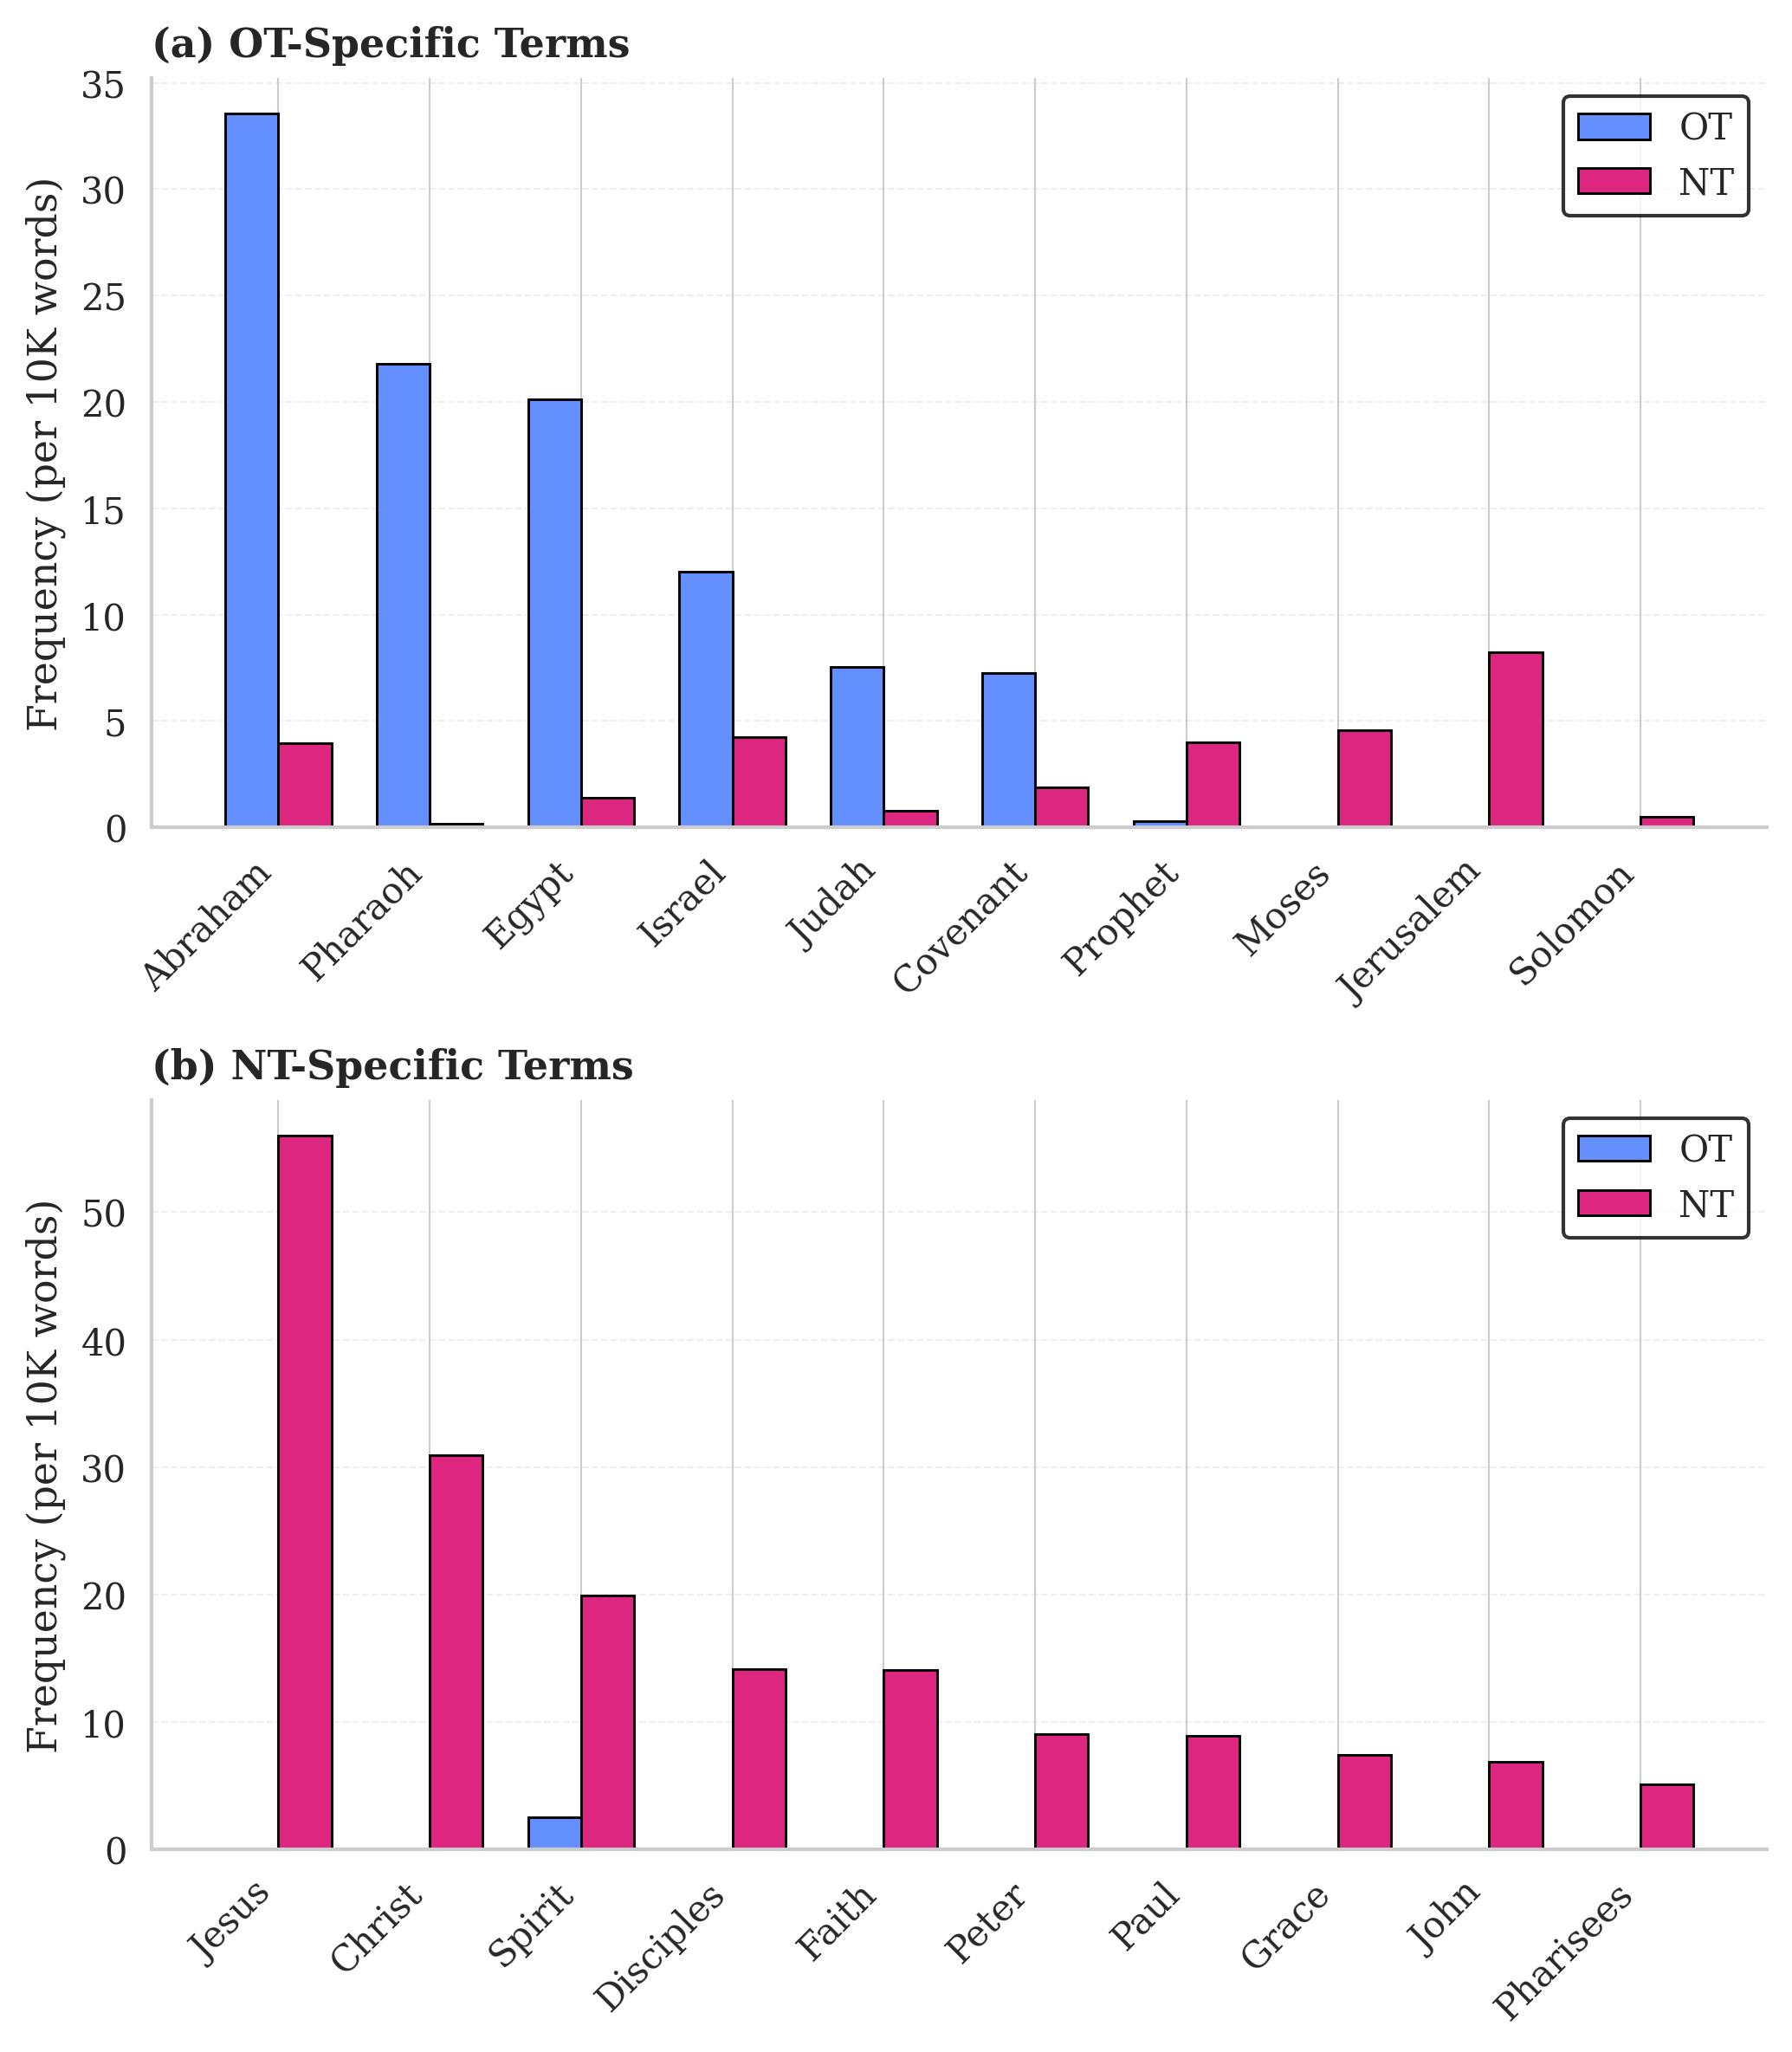

✓ Figure 4 saved: Key Terms Comparison


In [18]:
# Figure 4: Key Terms Frequency Comparison (Publication version)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# OT-specific terms (top 10 for clarity)
ot_terms_sorted = sorted(ot_term_data, key=lambda x: x[1], reverse=True)[:10]
terms_ot = [x[0].capitalize() for x in ot_terms_sorted]
ot_freq_normalized = [x[1] / ot_corpus_size * 10000 for x in ot_terms_sorted]
nt_freq_normalized_for_ot = [x[2] / nt_corpus_size * 10000 for x in ot_terms_sorted]

x = np.arange(len(terms_ot))
width = 0.35

bars1 = ax1.bar(x - width/2, ot_freq_normalized, width, 
                label='OT', color=colors_cb['blue'],
                edgecolor='black', linewidth=0.7)
bars2 = ax1.bar(x + width/2, nt_freq_normalized_for_ot, width,
                label='NT', color=colors_cb['magenta'],
                edgecolor='black', linewidth=0.7)

ax1.set_ylabel('Frequency (per 10K words)', fontsize=11)
ax1.set_title('(a) OT-Specific Terms', fontsize=11, loc='left', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(terms_ot, rotation=45, ha='right')
ax1.legend(loc='upper right', frameon=True, edgecolor='black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# NT-specific terms (top 10)
nt_terms_sorted = sorted(nt_term_data, key=lambda x: x[2], reverse=True)[:10]
terms_nt = [x[0].capitalize() for x in nt_terms_sorted]
ot_freq_normalized_for_nt = [x[1] / ot_corpus_size * 10000 for x in nt_terms_sorted]
nt_freq_normalized = [x[2] / nt_corpus_size * 10000 for x in nt_terms_sorted]

x2 = np.arange(len(terms_nt))

bars3 = ax2.bar(x2 - width/2, ot_freq_normalized_for_nt, width,
                label='OT', color=colors_cb['blue'],
                edgecolor='black', linewidth=0.7)
bars4 = ax2.bar(x2 + width/2, nt_freq_normalized, width,
                label='NT', color=colors_cb['magenta'],
                edgecolor='black', linewidth=0.7)

ax2.set_ylabel('Frequency (per 10K words)', fontsize=11)
ax2.set_title('(b) NT-Specific Terms', fontsize=11, loc='left', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(terms_nt, rotation=45, ha='right')
ax2.legend(loc='upper right', frameon=True, edgecolor='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig4_key_terms_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig4_key_terms_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ Figure 4 saved: Key Terms Comparison")


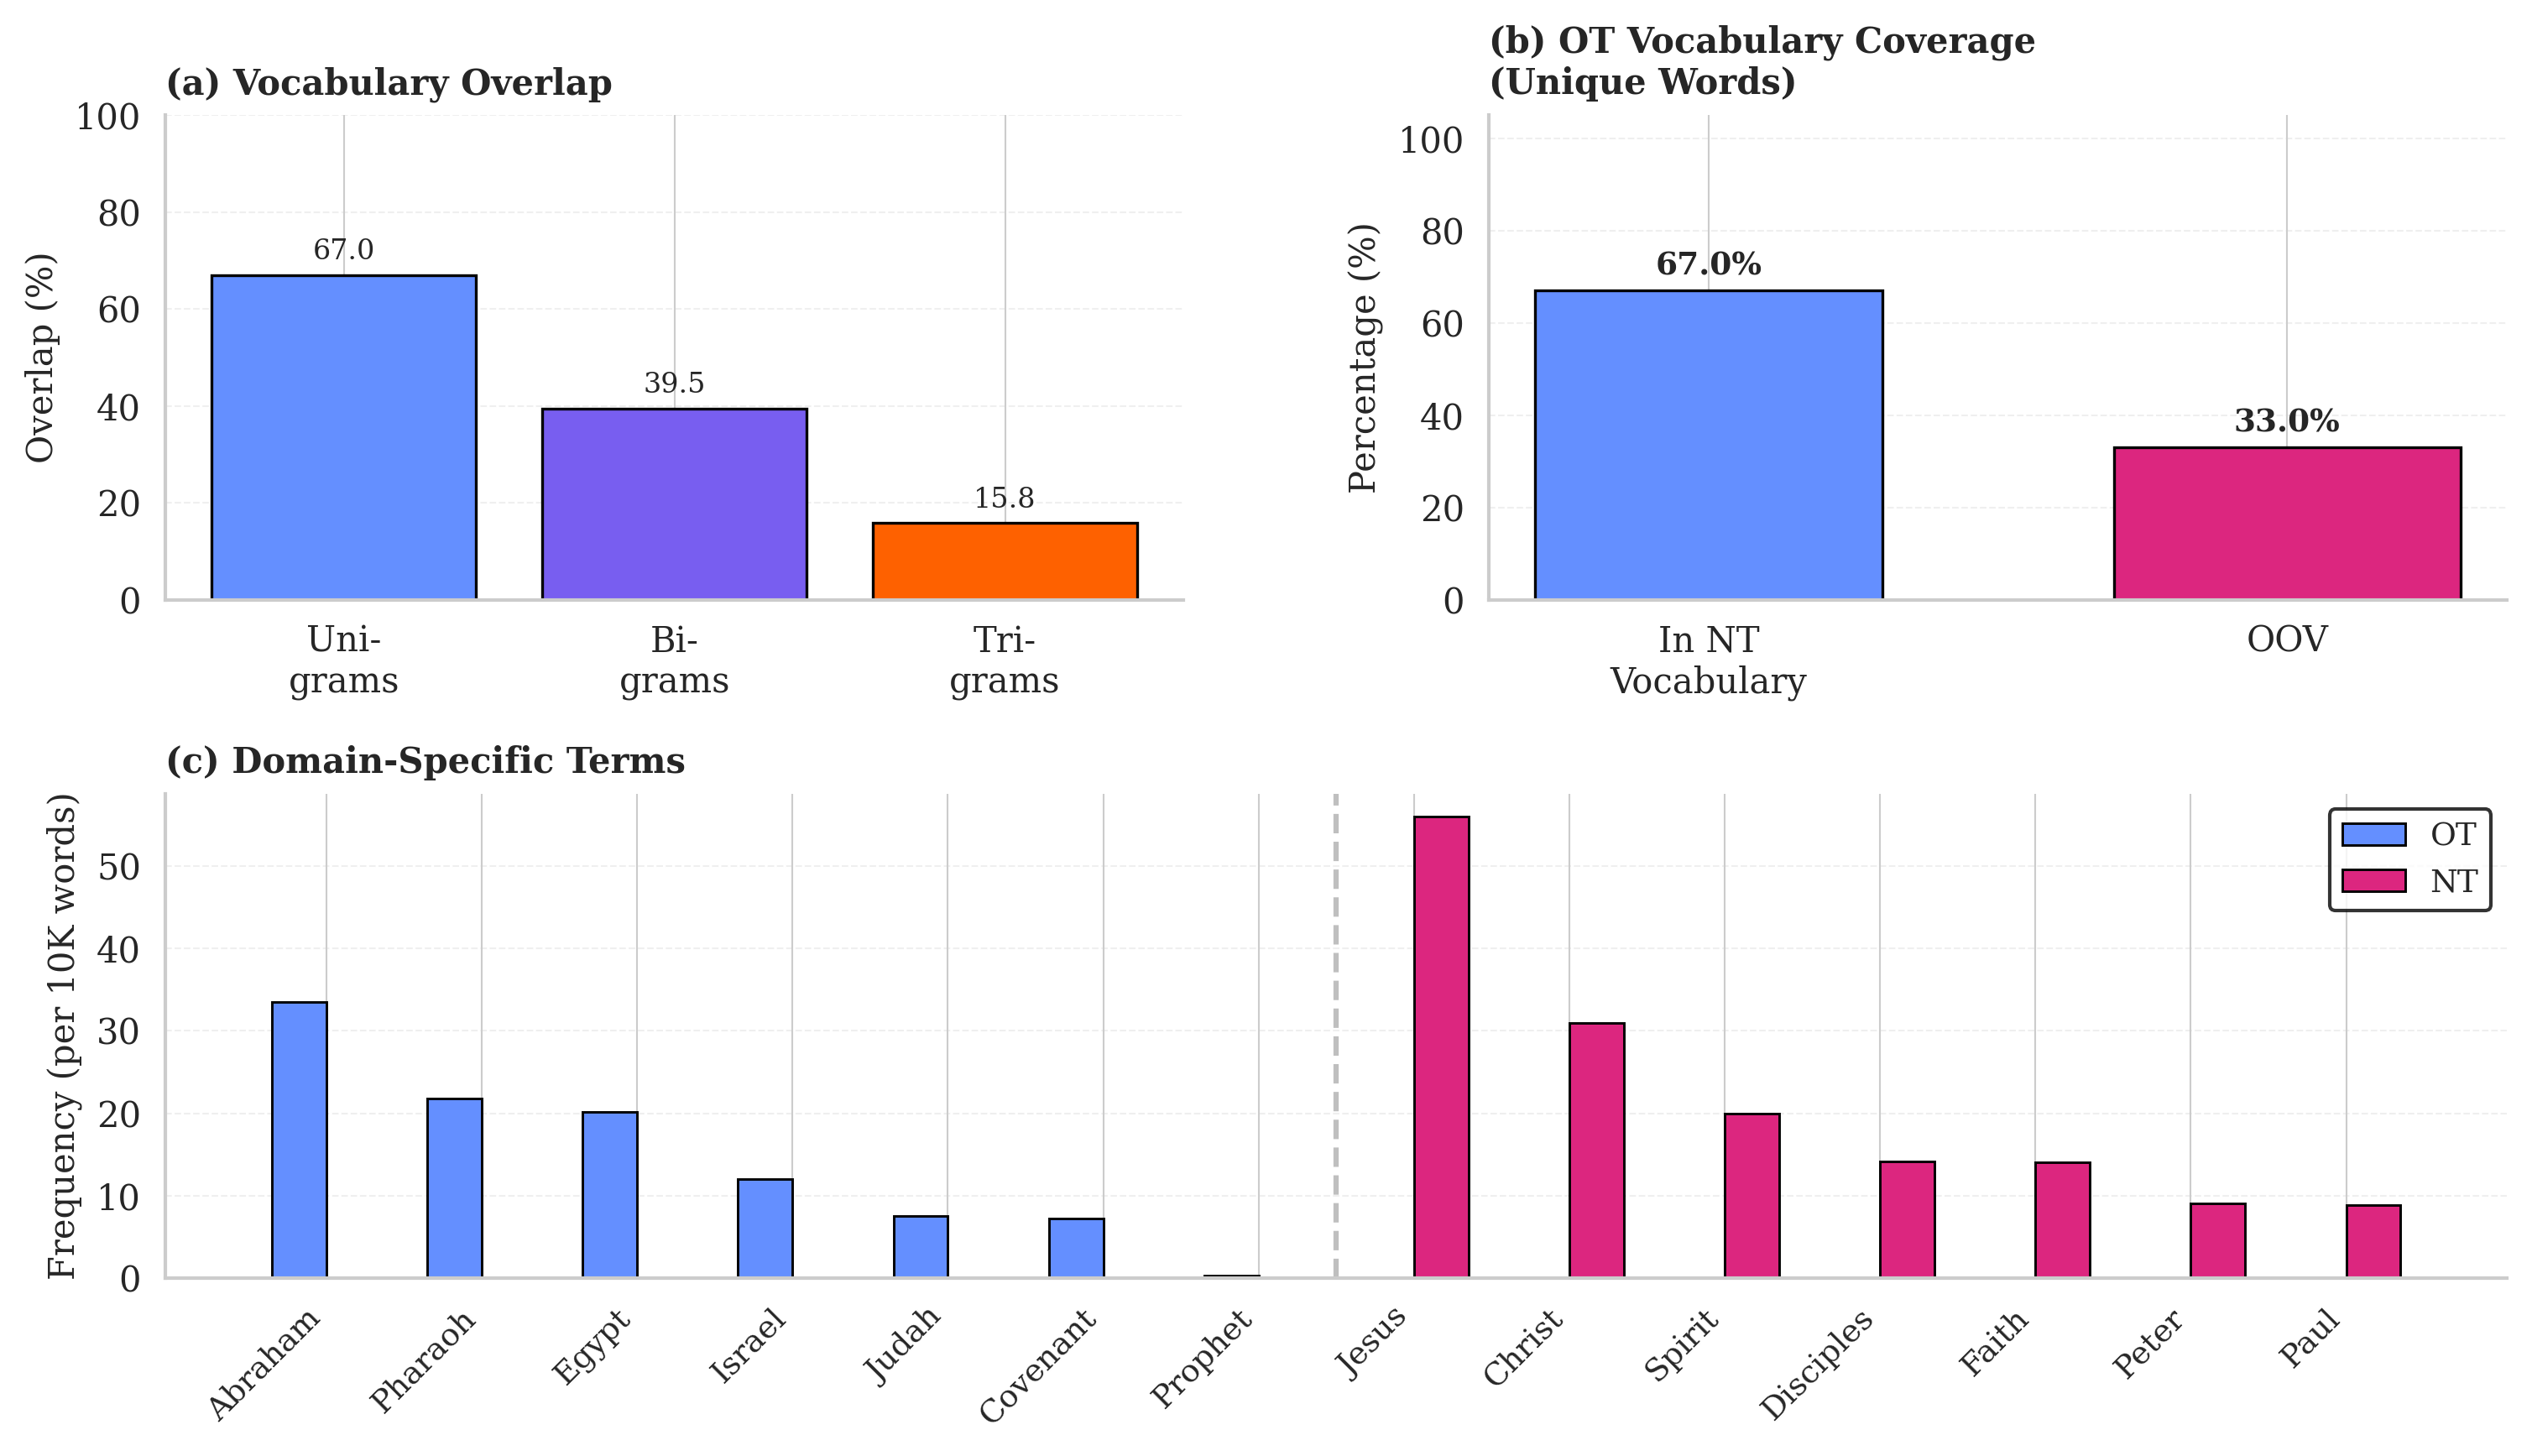

✓ Figure 5 saved: Combined Summary Figure


In [31]:
# Optional: Combined summary figure for maximum impact
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.3, height_ratios=[1, 1])

# Panel A: Vocabulary Overlap
ax1 = fig.add_subplot(gs[0, 0])
categories = ['Uni-\ngrams', 'Bi-\ngrams', 'Tri-\ngrams']
overlap_percentages = [unigram_overlap, bigram_overlap, trigram_overlap]
bars = ax1.bar(categories, overlap_percentages,
               color=[colors_cb['blue'], colors_cb['purple'], colors_cb['orange']],
               edgecolor='black', linewidth=0.8)
ax1.set_ylabel('Overlap (%)', fontsize=10)
ax1.set_ylim(0, 100)
ax1.set_title('(a) Vocabulary Overlap', fontsize=10, loc='left', fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, pct in zip(bars, overlap_percentages):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{pct:.1f}', ha='center', va='bottom', fontsize=8)

# Panel B: OOV Rate (Unique Words only)
ax2 = fig.add_subplot(gs[0, 1])
categories = ['In NT\nVocabulary', 'OOV']
values = [100 - oov_type_rate, oov_type_rate]

bars = ax2.bar(categories, values,
               color=[colors_cb['blue'], colors_cb['magenta']],
               edgecolor='black', linewidth=0.8, width=0.6)

ax2.set_ylabel('Percentage (%)', fontsize=10)
ax2.set_ylim(0, 105)
ax2.set_title('(b) OT Vocabulary Coverage\n(Unique Words)', fontsize=10, loc='left', fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel C: Domain-Specific Terms (Top 7 from each) - spans full width
ax3 = fig.add_subplot(gs[1, :])

# Get top 7 OT and NT terms
ot_top7 = sorted(ot_term_data, key=lambda x: x[1], reverse=True)[:7]
nt_top7 = sorted(nt_term_data, key=lambda x: x[2], reverse=True)[:7]

# Combine and prepare data
all_terms = [x[0].capitalize() for x in ot_top7] + [x[0].capitalize() for x in nt_top7]
ot_freqs = [x[1] / ot_corpus_size * 10000 for x in ot_top7] + [0] * 7
nt_freqs = [0] * 7 + [x[2] / nt_corpus_size * 10000 for x in nt_top7]

x = np.arange(len(all_terms))
width = 0.35

bars1 = ax3.bar(x - width/2, ot_freqs, width, label='OT', 
                color=colors_cb['blue'], edgecolor='black', linewidth=0.7)
bars2 = ax3.bar(x + width/2, nt_freqs, width, label='NT',
                color=colors_cb['magenta'], edgecolor='black', linewidth=0.7)

ax3.set_ylabel('Frequency (per 10K words)', fontsize=10)
ax3.set_title('(c) Domain-Specific Terms', fontsize=10, loc='left', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(all_terms, rotation=45, ha='right', fontsize=9)
ax3.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
# Add dividing line between OT and NT terms
ax3.axvline(x=6.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

plt.savefig('fig5_domain_shift_summary.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig5_domain_shift_summary.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ Figure 5 saved: Combined Summary Figure")


### Figure Recommendations for Your Paper

**For main text:**
- **Figure 1**: Vocabulary Overlap (simple, clear message)
- **Figure 3**: OOV Rate (demonstrates the core problem)
- **Figure 4**: Key Terms Comparison (shows domain-specific vocabulary)

**For supplementary materials:**
- **Figure 2**: Type-Token Ratio
- **Figure 5**: Combined summary (good for overview/discussion)

**Excluded from paper:**
- Word clouds (too informal for most academic venues)
- Pie charts (replaced with grouped bar charts)

All figures are saved in both PDF (vector, preferred for LaTeX) and PNG (raster, for Word/other) formats.
